In [1]:
!pip install requests pandas



In [2]:
import requests
import pandas as pd

# No-API-Key Weather API
url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 40.7128,
    "longitude": -74.0060,
    "hourly": "temperature_2m",
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame({
    "time": data["hourly"]["time"],
    "temperature": data["hourly"]["temperature_2m"]
})

df.head()


,time,temperature
0,2026-01-30T00:00,-9.8
1,2026-01-30T01:00,-10.1
2,2026-01-30T02:00,-11.4
3,2026-01-30T03:00,-12.2
4,2026-01-30T04:00,-12.5


In [3]:
df["time"] = pd.to_datetime(df["time"])
df.head()


,time,temperature
0,2026-01-30 00:00:00,-9.8
1,2026-01-30 01:00:00,-10.1
2,2026-01-30 02:00:00,-11.4
3,2026-01-30 03:00:00,-12.2
4,2026-01-30 04:00:00,-12.5


In [4]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         168 non-null    datetime64[ns]
 1   temperature  168 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.8 KB


,time,temperature
count,168,168.000000
mean,2026-02-02 11:30:00.000000256,-8.919048
min,2026-01-30 00:00:00,-22.600000
25%,2026-01-31 17:45:00,-11.400000
50%,2026-02-02 11:30:00,-9.200000
75%,2026-02-04 05:15:00,-5.500000
max,2026-02-05 23:00:00,-0.200000
std,NaN,4.838344


In [5]:
df["temperature"].mean()


np.float64(-8.91904761904762)

In [6]:
df["temperature"].max()


-0.2

In [7]:
df["temperature"].min()


-22.6

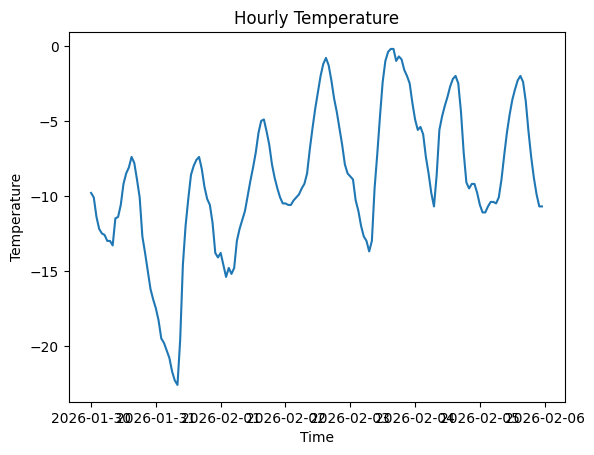

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["time"], df["temperature"])
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Hourly Temperature")
plt.show()